In [9]:
import os
os.makedirs('outputs', exist_ok=True)

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/train.csv')

print(df.shape)           # How many rows and columns?
print(df.head())          # First 5 rows
print(df.dtypes)          # Column types
print(df.isnull().sum())  # Missing values
print(df.describe())      # Stats summary

(1168, 27)
     Id Neighborhood BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
0   893      BrkSide     1Fam     1Story            7            8       1971   
1  1106      Veenker     1Fam     1.5Fin           10            7       1953   
2   414        NAmes   TwnhsE     1Story            7            2       1964   
3   523       BrDale     1Fam     1Story            5            5       1937   
4  1037      CollgCr     1Fam     SFoyer            7            5       1906   

   YearRemodAdd  GrLivArea  TotalBsmtSF  ...  GarageArea  LotArea  \
0          1994       1550         1208  ...         645    12594   
1          1981       1118          680  ...         238     8066   
2          1970       1680          908  ...         238     7114   
3          1964       1674          928  ...         166     3372   
4          1933       1019          743  ...         705     9523   

   LotFrontage  ExterQual  KitchenQual  BsmtQual  SaleCondition  MoSold  \
0           

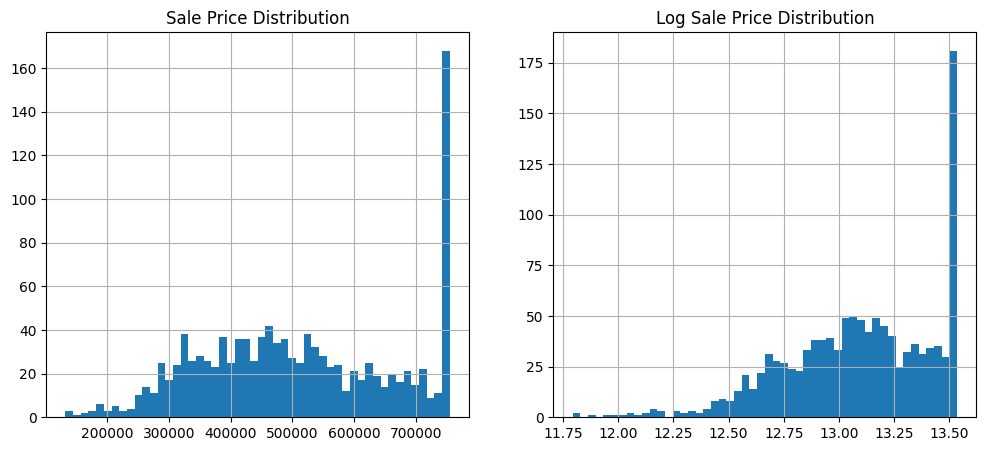

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of prices
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['SalePrice'].hist(bins=50)
plt.title('Sale Price Distribution')

plt.subplot(1, 2, 2)
np.log1p(df['SalePrice']).hist(bins=50)
plt.title('Log Sale Price Distribution')
plt.savefig('outputs/01_price_distribution.png')
plt.show()

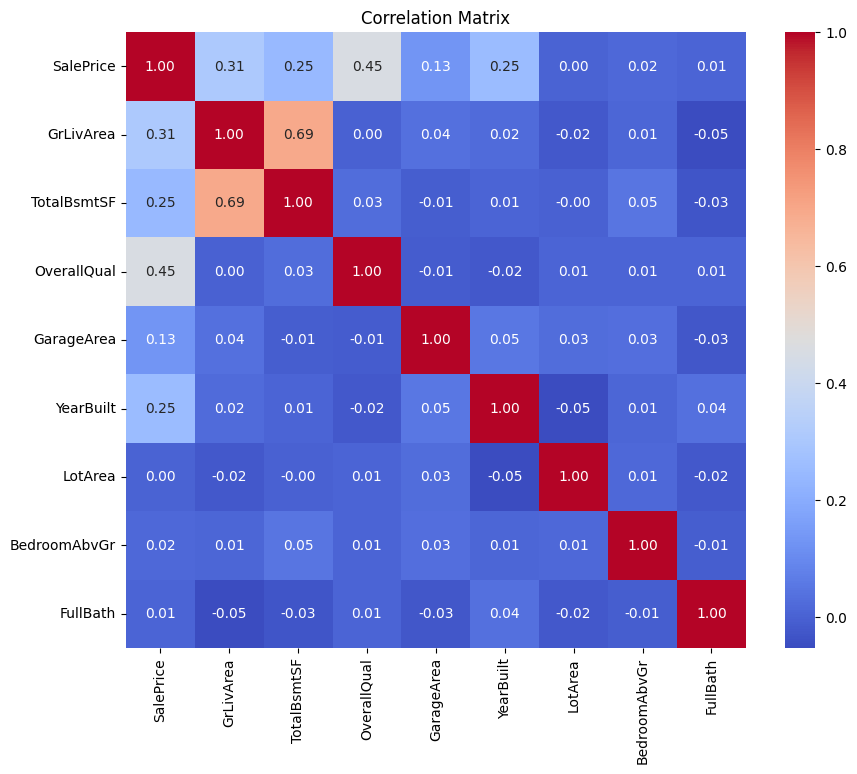

In [12]:
# Pick numeric columns
num_cols = ['SalePrice','GrLivArea','TotalBsmtSF','OverallQual',
            'GarageArea','YearBuilt','LotArea','BedroomAbvGr','FullBath']

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('outputs/02_correlation_heatmap.png') 
plt.show()

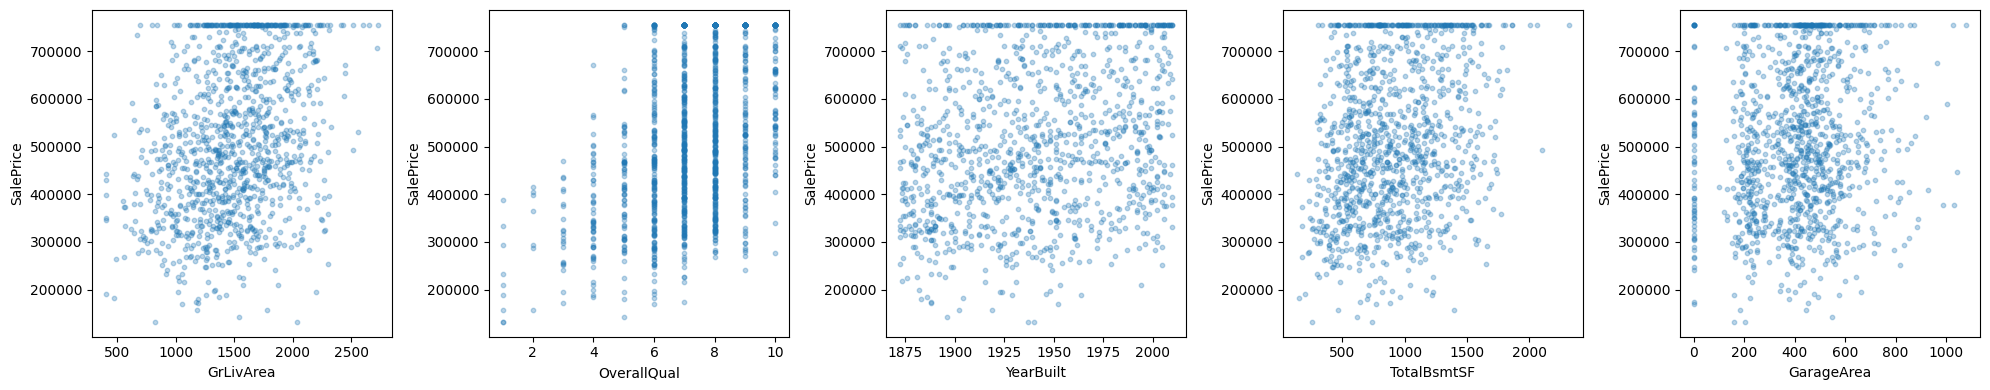

In [13]:
top_features = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageArea']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df['SalePrice'], alpha=0.3, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
plt.tight_layout()
plt.savefig('outputs/03_feature_scatter.png')  
plt.show()

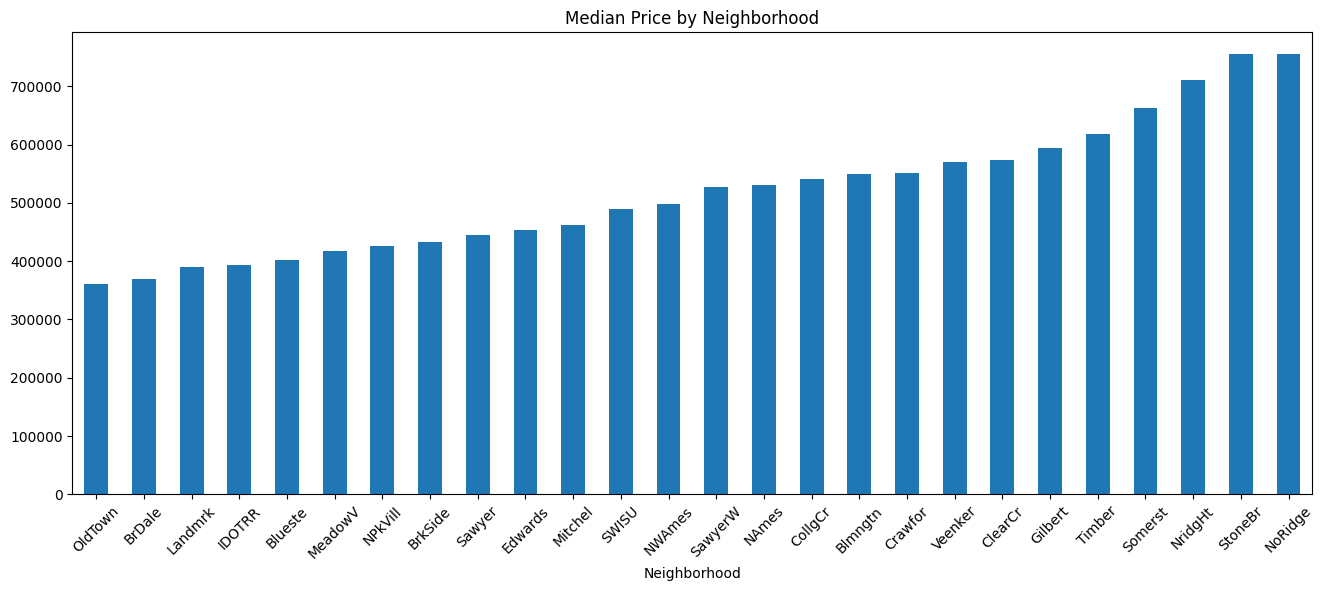

In [14]:
# Box plot — Price by Neighborhood
plt.figure(figsize=(16, 6))
df.groupby('Neighborhood')['SalePrice'].median().sort_values().plot(kind='bar')
plt.title('Median Price by Neighborhood')
plt.xticks(rotation=45)
plt.savefig('outputs/04_neighborhood_prices.png')
plt.show()

In [22]:
# Check which columns have missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# For numeric columns — fill with median
# For categorical columns — fill with 'None' or most frequent

BsmtQual    50
dtype: int64


In [30]:
import os

code = """
def engineer_features(df):
    d = df.copy()
    d['TotalSF']       = d['GrLivArea'] + d['TotalBsmtSF']
    d['HouseAge']      = 2010 - d['YearBuilt']
    d['WasRemodeled']  = (d['YearRemodAdd'] > d['YearBuilt']).astype(int)
    d['QualCondScore'] = d['OverallQual'] * d['OverallCond']
    d['TotalBaths']    = d['FullBath'] + 0.5 * d['HalfBath']
    d['QualAge']       = d['OverallQual'] / (d['HouseAge'] + 1)
    return d
"""

with open(r'C:\Users\PIYUSH\house-price-prediction\src\feature_engineering.py', 'w') as f:
    f.write(code)

print("✅ File created!")
print("Files in src:", os.listdir(r'C:\Users\PIYUSH\house-price-prediction\src'))

✅ File created!
Files in src: ['feature_engineering.py', 'generate_data.py', 'src']


In [31]:
import sys
sys.path.append(r'C:\Users\PIYUSH\house-price-prediction\src')

from feature_engineering import engineer_features

df = engineer_features(df)
print("✅ Features added!", df.shape)
print(df[['TotalSF', 'HouseAge', 'WasRemodeled', 'QualCondScore', 'TotalBaths', 'QualAge']].head())


✅ Features added! (1168, 33)
   TotalSF  HouseAge  WasRemodeled  QualCondScore  TotalBaths   QualAge
0     2758        39             1             56         2.0  0.175000
1     1798        57             1             70         1.0  0.172414
2     2588        46             1             14         2.5  0.148936
3     2602        73             1             25         1.0  0.067568
4     1762       104             1             35         0.0  0.066667


In [36]:
from sklearn.model_selection import train_test_split
import numpy as np

# Define features
NUMERIC_FEATURES = [
    'GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea',
    'OverallQual', 'OverallCond', 'YearBuilt', 'BedroomAbvGr',
    'FullBath', 'GarageCars', 'TotalSF', 'HouseAge',
    'WasRemodeled', 'QualCondScore', 'TotalBaths', 'QualAge'
]

CATEGORICAL_FEATURES = ['Neighborhood', 'BldgType', 'HouseStyle', 'SaleCondition']

# Split features and target
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = np.log1p(df['SalePrice'])

# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Split done!")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")




✅ Split done!
X_train: (934, 20)
X_val:   (234, 20)
y_train: (934,)
y_val:   (234,)


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
])

print("✅ Preprocessor ready!")

✅ Preprocessor ready!


In [38]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=10),
    'Lasso':             Lasso(alpha=0.001, max_iter=10000),
    'ElasticNet':        ElasticNet(alpha=0.001, l1_ratio=0.5),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])

    cv_scores = cross_val_score(
        pipe, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )

    pipe.fit(X_train, y_train)

    val_preds  = np.expm1(pipe.predict(X_val))
    val_actual = np.expm1(y_val)

    r2   = r2_score(val_actual, val_preds)
    rmse = np.sqrt(mean_squared_error(val_actual, val_preds))

    results[name] = {
        'R2':       r2,
        'RMSE':     rmse,
        'CV_RMSLE': -cv_scores.mean()
    }

    print(f"{name:22s} | R²={r2:.4f} | RMSE=${rmse:,.0f} | CV={-cv_scores.mean():.4f}")

print("\n✅ All models trained!")


Linear Regression      | R²=0.7364 | RMSE=$81,699 | CV=0.1974
Ridge                  | R²=0.7208 | RMSE=$84,091 | CV=0.2010
Lasso                  | R²=0.7340 | RMSE=$82,074 | CV=0.1970
ElasticNet             | R²=0.7391 | RMSE=$81,293 | CV=0.1967
Random Forest          | R²=0.4886 | RMSE=$113,811 | CV=0.2426
Gradient Boosting      | R²=0.6544 | RMSE=$93,556 | CV=0.2174

✅ All models trained!


In [39]:
# Find best model by lowest CV_RMSLE
best_name = min(results, key=lambda k: results[k]['CV_RMSLE'])
print(f"🏆 Best model: {best_name}")
print(f"   R²       : {results[best_name]['R2']:.4f}")
print(f"   RMSE     : ${results[best_name]['RMSE']:,.0f}")
print(f"   CV RMSLE : {results[best_name]['CV_RMSLE']:.4f}")

🏆 Best model: ElasticNet
   R²       : 0.7391
   RMSE     : $81,293
   CV RMSLE : 0.1967


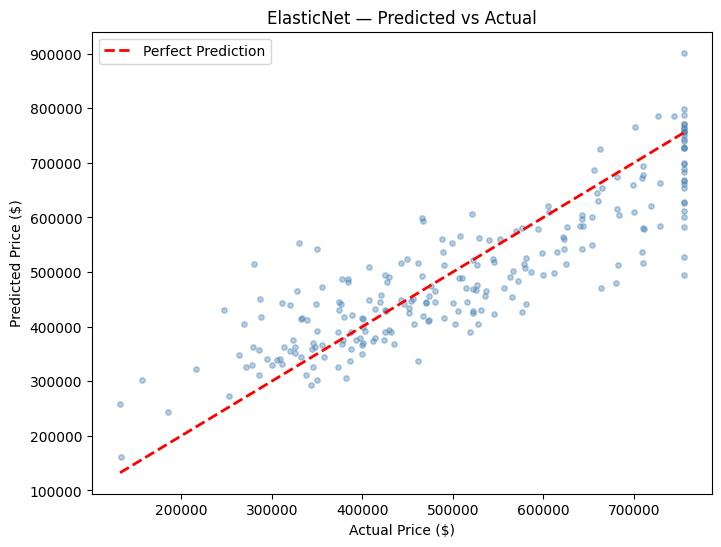

✅ Chart saved!


In [40]:
import matplotlib.pyplot as plt
import os
os.makedirs('../outputs', exist_ok=True)

# Retrain best model on full training data
best_pipe = Pipeline([('preprocessor', preprocessor), ('model', models[best_name])])
best_pipe.fit(X_train, y_train)

# Get predictions
val_preds  = np.expm1(best_pipe.predict(X_val))
val_actual = np.expm1(y_val)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(val_actual, val_preds, alpha=0.4, color='steelblue', s=15)
plt.plot(
    [val_actual.min(), val_actual.max()],
    [val_actual.min(), val_actual.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'{best_name} — Predicted vs Actual')
plt.legend()

plt.savefig('../outputs/06_predicted_vs_actual.png')
plt.show()
print("✅ Chart saved!")

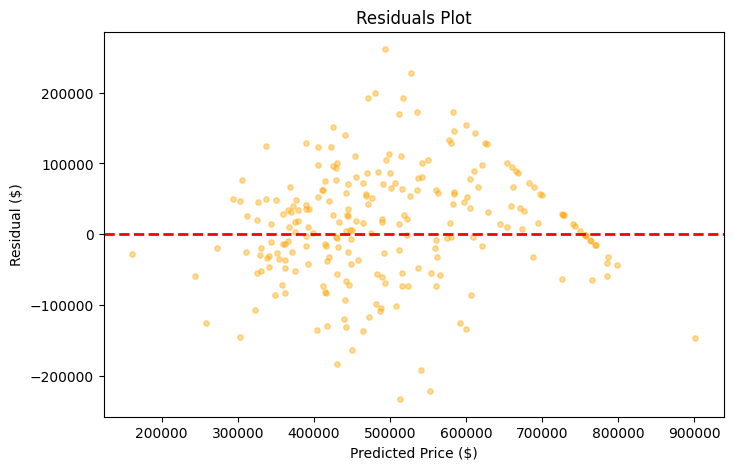

✅ Residuals chart saved!


In [41]:
residuals = val_actual - val_preds

plt.figure(figsize=(8, 5))
plt.scatter(val_preds, residuals, alpha=0.4, color='orange', s=15)
plt.axhline(0, color='red', linewidth=2, linestyle='--')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual ($)')
plt.title('Residuals Plot')

plt.savefig('../outputs/07_residuals.png')
plt.show()
print("✅ Residuals chart saved!")

C:\Users\PIYUSH\AppData\Local\Temp\ipykernel_2804\2677965091.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(model_names, rotation=30, ha='right')
C:\Users\PIYUSH\AppData\Local\Temp\ipykernel_2804\2677965091.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=30, ha='right')


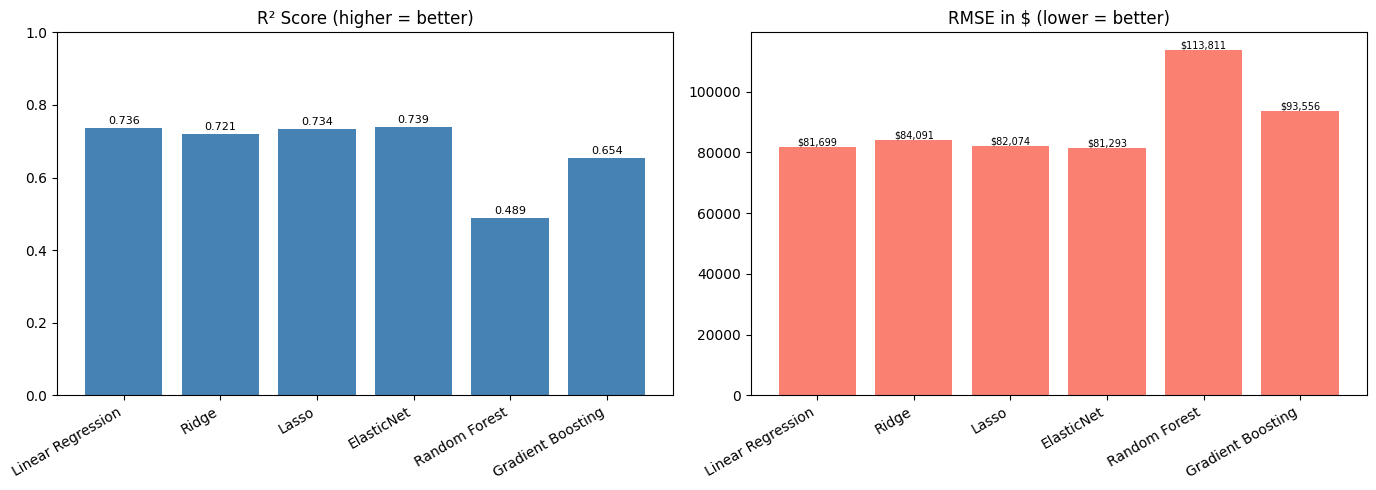

✅ Model comparison chart saved!


In [42]:
model_names = list(results.keys())
r2_scores   = [results[m]['R2']   for m in model_names]
rmse_scores = [results[m]['RMSE'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² chart
axes[0].bar(model_names, r2_scores, color='steelblue')
axes[0].set_title('R² Score (higher = better)')
axes[0].set_xticklabels(model_names, rotation=30, ha='right')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

# RMSE chart
axes[1].bar(model_names, rmse_scores, color='salmon')
axes[1].set_title('RMSE in $ (lower = better)')
axes[1].set_xticklabels(model_names, rotation=30, ha='right')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('../outputs/05_model_comparison.png')
plt.show()
print("✅ Model comparison chart saved!")

In [43]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(best_pipe, '../models/best_model.pkl')
print(f"✅ Model saved → models/best_model.pkl")

✅ Model saved → models/best_model.pkl


In [44]:
# Load test data
test_df = pd.read_csv('../data/test.csv')

# Apply same feature engineering
test_df = engineer_features(test_df)

# Predict
log_preds   = best_pipe.predict(test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES])
predictions = np.expm1(log_preds)

# Save submission file
submission = pd.DataFrame({
    'Id':        test_df['Id'],
    'SalePrice': predictions
})
submission.to_csv('../outputs/submission.csv', index=False)

print("✅ Predictions saved → outputs/submission.csv")
print(submission.head())

✅ Predictions saved → outputs/submission.csv
   Id      SalePrice
0   2  248986.360192
1   9  374911.579574
2  14  553051.803940
3  15  703502.460380
4  21  418273.579770


In [45]:
print("=" * 50)
print("✅ PROJECT COMPLETE")
print("=" * 50)
print(f"  Best Model : {best_name}")
print(f"  R²         : {results[best_name]['R2']:.4f}")
print(f"  RMSE       : ${results[best_name]['RMSE']:,.0f}")
print(f"  CV RMSLE   : {results[best_name]['CV_RMSLE']:.4f}")
print("=" * 50)
print("\n📁 Files saved:")
print("  outputs/05_model_comparison.png")
print("  outputs/06_predicted_vs_actual.png")
print("  outputs/07_residuals.png")
print("  outputs/submission.csv")
print("  models/best_model.pkl")


✅ PROJECT COMPLETE
  Best Model : ElasticNet
  R²         : 0.7391
  RMSE       : $81,293
  CV RMSLE   : 0.1967

📁 Files saved:
  outputs/05_model_comparison.png
  outputs/06_predicted_vs_actual.png
  outputs/07_residuals.png
  outputs/submission.csv
  models/best_model.pkl
